### Questao 1.1: Quantas instâncias e quantos atributos existem?

In [1]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
display(df.shape)

(119390, 32)

### Questao 1.2: Quais atributos são numéricos e quais são categóricos?

In [2]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
display(df.dtypes)


def verifyAtribute(df):
    countC = 0
    countN = 0

    for column in df.columns:
        if df[column].dtype != 'str' and df[column].nunique() != 2:
            countN += 1
        else:
            countC += 1

    return countC, countN

categoricos, numericos = verifyAtribute(df)

print("Categóricos:", categoricos)
print("Numéricos:", numericos)



hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

Categóricos: 14
Numéricos: 18


### Questao 1.3: Quais atributos são binários?

In [3]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def verifyBi(df):
    result = []

    for column in df.columns:
        if df[column].nunique() == 2:
            result.append({
                'Attribute': column,
                'Values': df[column].dropna().unique()
            })

    return result

display(pd.DataFrame(verifyBi(df)))

,Attribute,Values
0,hotel,"[Resort Hotel, City Hotel]"
1,is_canceled,"[0, 1]"
2,is_repeated_guest,"[0, 1]"


### Questao 1.4: Quais atributos representam características da reserva, do cliente, da estadia e do hotel?

In [4]:
##Pulei por enquanto


### Questao 2.5: Existem valores faltantes? Em quais atributos e em que quantidade? 

In [5]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def valueOff(df):
    result = []

    for column in df.columns:
        null_count = df[column].isnull().sum()

        if null_count != 0:
            result.append({
                'Attribute': column,
                'Null Values': null_count
            })

    return result


display(pd.DataFrame(valueOff(df)))

,Attribute,Null Values
0,children,4
1,country,488
2,agent,16340
3,company,112593


### Questao 2.6: Existem registros duplicados? 

In [6]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
df.duplicated().sum()

np.int64(31994)

### Questao 2.7: Quais atributos possuem grande quantidade de valores distintos?

In [7]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')

def verifyDistinct(df):
    result = []
    for column in df.columns:
        if df[column].nunique() >= 100:
            result.append({'atrubute': column, 'distinc values': df[column].nunique()}) 
    return result

display(pd.DataFrame(verifyDistinct(df)))


,atrubute,distinc values
0,lead_time,479
1,country,177
2,agent,333
3,company,352
4,days_in_waiting_list,128
5,adr,8879
6,reservation_status_date,926


### Questao 2.8: Quais problemas de qualidade precisam ser considerados antes de uma análise posterior?
Resposta: Entre esses casos, acredito que devam ser tartados: 
- Valores Nulos(NaN), podem vir a prejudicar a analise desses dados. 
- Valores com linhas duplicadas, podem vir a distorcer as analises.
- Os atributos com valores extremos que podem significar a presenca de outliers.

### Questao 3: Calcule média, mediana, mínimo, máximo, quartis, amplitude, IQR e desvio padrão para os principais atributos numéricos.
Nesse arquivo eu vou fazer duas funcoes, uma pra pegar exatamente as colunas especificas apresentadas e outra para usar em qualquer csv generica, pegando e calculando para todas as colunas


In [8]:
import pandas as pd

df = pd.read_csv('hotel_bookings.csv')
df.describe()

#Funcao Especifica
def func1(df):
    attributes = [
        'lead_time',
        'stays_in_weekend_nights',
        'stays_in_week_nights',
        'adults',
        'children',
        'babies',
        'previous_cancellations',
        'booking_changes',
        'days_in_waiting_list',
        'adr',
        'total_of_special_requests'
    ]
    stats = df[attributes].describe()
    stats.loc['amplitude'] = stats.loc['max'] - stats.loc['min']
    stats.loc['IQR'] = stats.loc['75%'] - stats.loc['25%']
    return stats

display(func1(df))

#Funcao generica
# def func2(df):
#     stats = df.describe()
#     stats.loc['amplitude'] = stats.loc['max'] - stats.loc['min']
#     stats.loc['IQR'] = stats.loc['75%'] - stats.loc['25%']
#     return stats

# display(func2(df))

    

,lead_time,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,previous_cancellations,booking_changes,days_in_waiting_list,adr,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,0.927599,2.500302,1.856403,0.103890,0.007949,0.087118,0.221124,2.321149,101.831122,0.571363
std,106.863097,0.998613,1.908286,0.579261,0.398561,0.097436,0.844336,0.652306,17.594721,50.535790,0.792798
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000
25%,18.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000
50%,69.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000
75%,160.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,1.000000
max,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5400.000000,5.000000
amplitude,737.000000,19.000000,50.000000,55.000000,10.000000,10.000000,26.000000,21.000000,391.000000,5406.380000,5.000000
IQR,142.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,56.710000,1.000000


### Gráfico 1 – Distribuição do tempo de antecedência das reservas

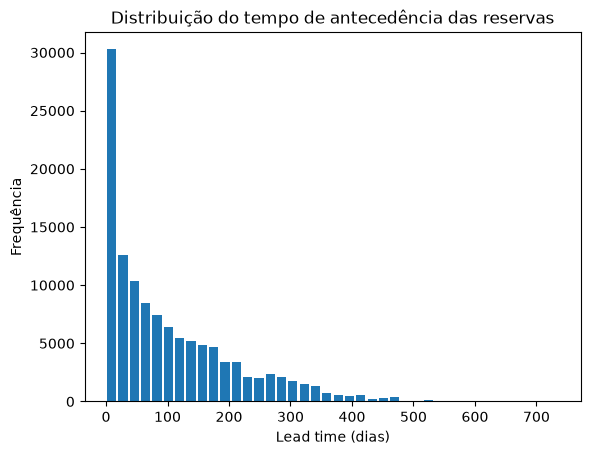

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

%matplotlib inline

df['lead_time'].plot.hist(
    bins=40,
    rwidth=0.8
)

plt.title('Distribuição do tempo de antecedência das reservas')
plt.xlabel('Lead time (dias)')
plt.ylabel('Frequência')

plt.show()

#### 4.1 - Em que faixa de antecedência está concentrada a maior parte das reservas?

Resposta: A maior parte das reservas está concentrada entre 0 e 100 dias de antecedência.

#### 4.2 - A distribuição parece simétrica ou assimétrica?

Resposta: A distribuição é assimétrica à direita (assimetria positiva), pois a maioria das reservas possui baixa antecedência, enquanto a cauda se estende para valores mais elevados.

#### 4.3 - Existe uma cauda longa para valores elevados?

Resposta: Sim. Existe uma cauda longa que se estende para valores elevados de *lead time*, embora essas reservas ocorram com baixa frequência.

#### 4.4 - Há indícios de valores extremos?

Resposta: Sim. As reservas com valores de *lead time* muito elevados, especialmente acima de 500 dias, podem representar valores extremos. A alta frequência entre 0 e 20 dias não indica um valor extremo, mas sim a faixa em que há maior concentração de reservas.

#### 4.5 - O que o formato sugere sobre o planejamento das reservas?

Resposta: O formato sugere que a maioria dos clientes prefere fazer reservas com pouca antecedência. Entretanto, há um grupo menor de clientes que planeja suas reservas com muita antecedência.

### Gráfico 2 – Distribuição do preço médio diário (ADR)

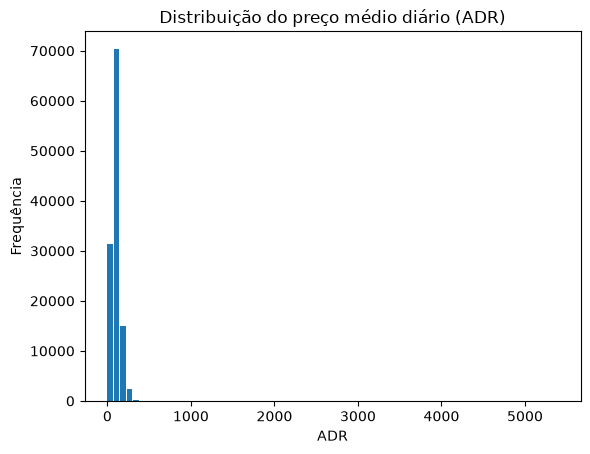

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df['adr'].plot.hist(
    bins=70,
    rwidth=0.9
)

plt.title('Distribuição do preço médio diário (ADR)')
plt.xlabel('ADR')
plt.ylabel('Frequência')

plt.show()

# isso aqui foi so pra conferir, nao eh necessario nao
# display(df['adr'].describe())
# display(df['adr'].sort_values(ascending=False).head(20))

#### 4.6 - Em qual faixa de preço está concentrada a maior parte das reservas?
Resposta: A maior concentracao esta ali por volta de 0 e 200 aproximadamente.

#### 4.7 - A distribuição apresenta assimetria?
Resposta: Sim, a distribuicao apresenta assimetria positiva, devido a alta concentracao a direita.

#### 4.8 - Existem valores muito afastados da concentração principal?
Resposta: Sim. Embora a maioria dos valores de ADR esteja concentrada nas primeiras faixas do histograma, existem poucos registros muito distantes dessa concentração, incluindo um valor próximo de 5.400. Esses registros podem representar possíveis valores extremos.

#### 4.9 - A média parece representar bem o preço típico? Compare com a mediana.
Resposta: A média do ADR é aproximadamente 101,83, enquanto a mediana é 94,58. A média é maior porque os valores extremos elevados a puxam para cima. Assim, a mediana representa melhor o preço típico, pois é menos influenciada por valores extremos.

#### 4.10 - Que cuidados devem ser tomados ao utilizar ADR em análises posteriores?
Resposta: Deve-se considerar a forte assimetria da distribuição e investigar os valores extremos para verificar se representam casos reais ou erros.

### Gráfico 3 – Boxplot do ADR por tipo de hotel

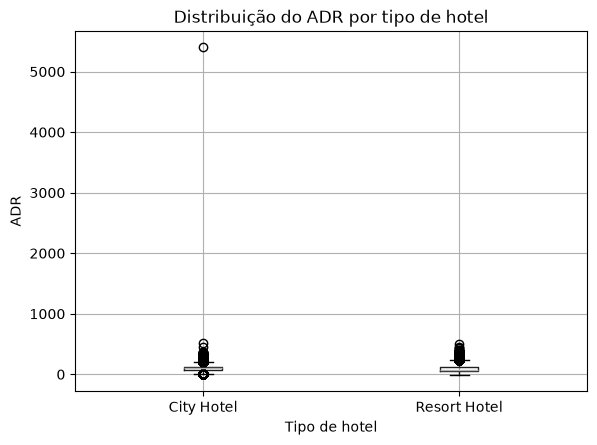

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df.boxplot(
    column='adr',
    by='hotel'
)

plt.title('Distribuição do ADR por tipo de hotel')
plt.suptitle('')

plt.xlabel('Tipo de hotel')
plt.ylabel('ADR')

plt.show()

## grupo teste
# df.groupby('hotel')['adr'].describe()
# df.nlargest(10, 'adr')[['hotel', 'adr']]

#### 4.11 - Qual tipo de hotel apresenta maior mediana?
Resposta: O City Hotel

#### 4.12 - Qual apresenta maior dispersão?
Resposta: O Resort Hotel

#### 4.13 - Os intervalos interquartis são semelhantes?
Resposta: Não. O Resort Hotel apresenta um intervalo interquartil maior.

#### 4.14 - Há mais valores extremos em um dos grupos?
Resposta: Sim, no City Hotel tem mais possiveis valores extremos.

#### 4.15 - Os preços dos dois hotéis apresentam comportamentos semelhantes?
Resposta: Aparentemente sim, ambas possuem assimetria positiva.

### Gráfico 4 – Cancelamentos por tipo de hotel

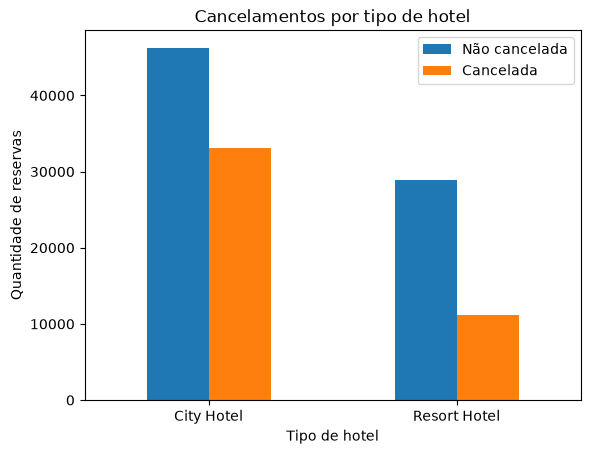

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

cancellations = df.groupby(
    ['hotel', 'is_canceled']
).size().unstack()

cancellations.plot(
    kind='bar'
)

plt.title('Cancelamentos por tipo de hotel')
plt.xlabel('Tipo de hotel')
plt.ylabel('Quantidade de reservas')
plt.legend(['Não cancelada', 'Cancelada'])
plt.xticks(rotation=0)

plt.show()

#### 4.16 - Qual hotel possui maior número absoluto de cancelamentos?
Resposta: O city Hotel possui um numero maior de cancelamentos.

#### 4.17 - Qual apresenta maior proporção de cancelamentos?\
Resposta: O City Hotel também apresenta a maior proporção de cancelamentos.

#### 4.18 - Por que apenas o número absoluto pode levar a uma interpretação equivocada?
Resposta: O número absoluto pode levar a uma interpretação equivocada porque os hotéis possuem quantidades diferentes de reservas. Como o City Hotel possui mais reservas no total, é esperado que também possa apresentar mais cancelamentos.

#### 4.19 - O comportamento de cancelamento parece diferir entre os hotéis?
Resposta: Sim. O City Hotel apresenta maior quantidade e maior proporção de cancelamentos. Isso indica que o cancelamento é mais frequente no City Hotel do que no Resort Hotel.

### Gráfico 5 – Cancelamento e antecedência da reserva

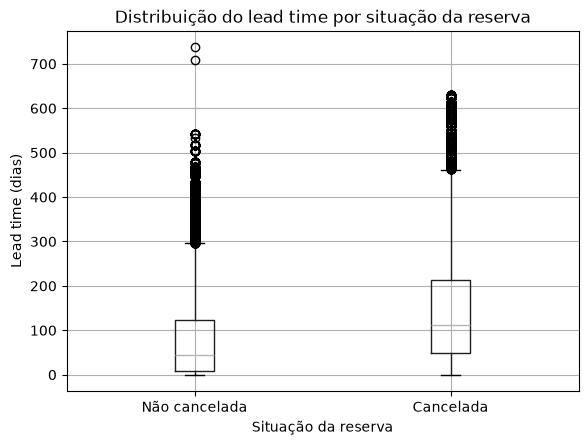

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df.boxplot(
    column='lead_time',
    by='is_canceled'
)

plt.title('Distribuição do lead time por situação da reserva')
plt.suptitle('')

plt.xlabel('Situação da reserva')
plt.ylabel('Lead time (dias)')

plt.xticks(
    [1, 2],
    ['Não cancelada', 'Cancelada']
)

plt.show()

#### 4.20 - Qual grupo apresenta maior mediana de antecedência?

Resposta: As reservas canceladas apresentam a maior mediana de antecedência, com aproximadamente 113 dias. Nas reservas não canceladas, a mediana é de 45 dias.

#### 4.21 - Qual grupo apresenta maior dispersão?

Resposta: As reservas canceladas apresentam maior dispersão. Seu intervalo interquartil é de aproximadamente 166 dias, enquanto o das reservas não canceladas é de 115 dias.

#### 4.22 - As reservas canceladas parecem ter sido feitas com maior antecedência?

Resposta: Sim. As reservas canceladas possuem mediana e quartis mais elevados, indicando que, em geral, foram realizadas com maior antecedência.

#### 4.23 - O gráfico fornece evidência de uma possível relação entre antecedência e cancelamento?

Resposta: Sim. O gráfico mostra que as reservas canceladas tendem a apresentar valores maiores de `lead_time`. Isso sugere uma possível associação entre maior antecedência e cancelamento, mas o boxplot sozinho não comprova uma relação de causa e efeito.

#### 4.24 - Que hipótese sobre cancelamentos poderia ser investigada depois?

Resposta: Uma hipótese a ser investigada é que reservas feitas com maior antecedência apresentam maior probabilidade de cancelamento. Essa hipótese pode ser avaliada comparando as taxas de cancelamento por faixas de `lead_time` ou utilizando um modelo estatístico.

### Gráfico 6 – Demanda ao longo do ano

hotel,City Hotel,Resort Hotel
arrival_date_month,,
January,3736,2193
February,4965,3103
March,6458,3336
April,7480,3609
May,8232,3559
June,7894,3045
July,8088,4573
August,8983,4894
September,7400,3108


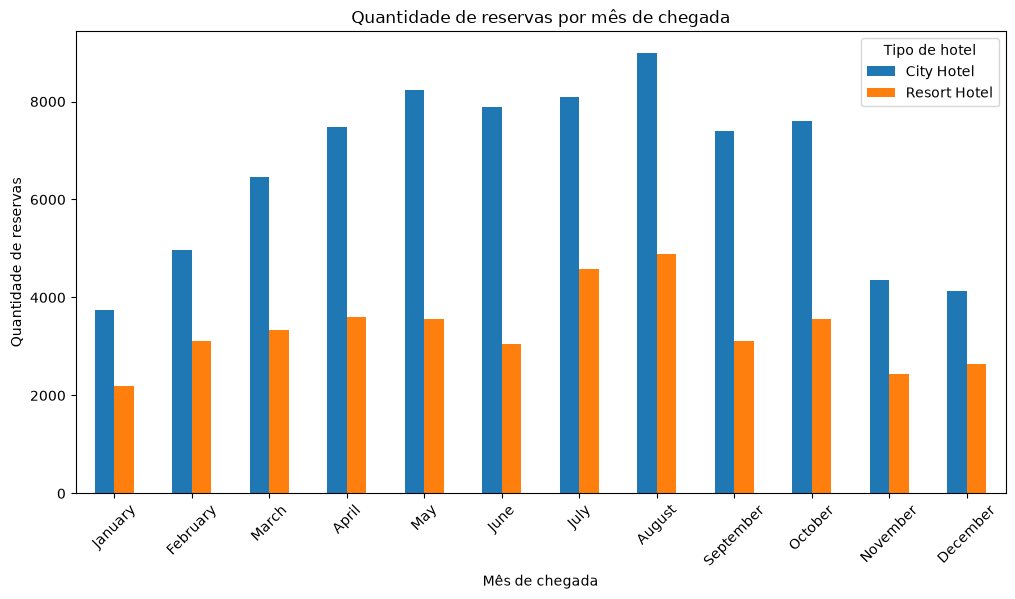

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

monthly_demand = (
    df.groupby(['arrival_date_month', 'hotel'])
      .size()
      .unstack()
      .reindex(month_order)
)

display(monthly_demand)

monthly_demand.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Quantidade de reservas por mês de chegada')
plt.xlabel('Mês de chegada')
plt.ylabel('Quantidade de reservas')

plt.xticks(rotation=45)

plt.legend(title='Tipo de hotel')

plt.show()

#### 4.25 — Quais meses apresentam maior volume de reservas?

Resposta: Agosto apresenta o maior volume total, com 13.877 reservas, seguido por julho, com 12.661. Maio também apresenta um volume elevado, com 11.791 reservas.

#### 4.26 - Existem períodos de baixa demanda?

Resposta: Sim. Janeiro apresenta o menor volume, com 5.929 reservas. Novembro e dezembro também apresentam demanda relativamente baixa, com aproximadamente 6.800 reservas em cada mês.

#### 4.27 - O padrão é semelhante nos dois hotéis?

Resposta: O padrão é parcialmente semelhante. Os dois hotéis apresentam aumento da demanda em julho e agosto e volumes mais baixos em janeiro, novembro e dezembro. Entretanto, o City Hotel possui mais reservas em todos os meses.

#### 4.28 - Em quais períodos as diferenças são mais evidentes?

Resposta: As diferenças absolutas são mais evidentes entre maio e outubro, especialmente em junho, quando o City Hotel possui aproximadamente 4.849 reservas a mais que o Resort Hotel. Maio e setembro também apresentam diferenças elevadas.

#### 4.29 - Que implicação isso poderia ter para o planejamento de capacidade ou preços?

Resposta: Nos meses de maior demanda, os hotéis podem aumentar a capacidade operacional, ajustar as escalas de funcionários e adotar preços mais elevados. Nos períodos de baixa demanda, podem utilizar promoções e preços mais competitivos para estimular novas reservas.

### Gráfico 7 – Relação entre antecedência e preço

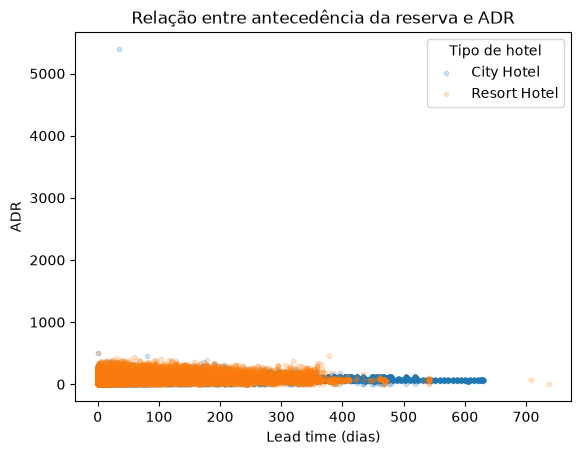

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

for hotel, grupo in df.groupby('hotel'):
    plt.scatter(
        grupo['lead_time'],
        grupo['adr'],
        alpha=0.2,
        s=10,
        label=hotel
    )

plt.title('Relação entre antecedência da reserva e ADR')
plt.xlabel('Lead time (dias)')
plt.ylabel('ADR')
plt.legend(title='Tipo de hotel')
plt.show()

#### 4.30 - É possível observar uma tendência entre antecedência e preço?

Resposta: Não é possível observar uma tendência forte e claramente definida. Os pontos estão bastante dispersos, indicando que reservas com diferentes antecedências podem apresentar valores semelhantes de ADR.

#### 4.31 - A relação parece positiva, negativa ou inexistente?

Resposta: A relação geral parece praticamente inexistente, com uma tendência negativa muito fraca. A correlação entre `lead_time` e ADR é de aproximadamente −0,063, valor muito próximo de zero.

#### 4.32 - O padrão é diferente entre os hotéis?

Resposta: A diferença é pequena. No City Hotel, existe uma relação negativa fraca, com correlação de aproximadamente −0,137. No Resort Hotel, a correlação é aproximadamente 0,031, indicando praticamente nenhuma relação linear. Entretanto, o gráfico atual não diferencia os hotéis visualmente.

#### 4.33 - Há regiões de grande concentração?

Resposta: Sim. Existe maior concentração de reservas nos valores mais baixos e intermediários de `lead_time`, principalmente abaixo de 200 dias, e em valores de ADR próximos da faixa principal da distribuição, geralmente abaixo de 200.

#### 4.34 - Existem pontos que fogem do padrão geral?

Resposta: Sim. Há pontos com valores muito elevados de ADR, especialmente o registro próximo de 5.400, além de reservas com `lead_time` superior a 600 dias. Esses pontos podem ser considerados possíveis valores extremos.

### Gráfico 8 – Relação entre duração da estadia e preço

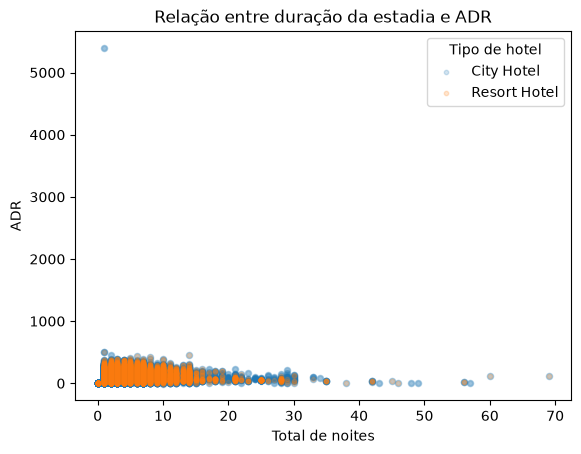

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

df['total_nights'] = (
    df['stays_in_weekend_nights']
    + df['stays_in_week_nights']
)

# Scatter plot
df.plot.scatter(
    x='total_nights',
    y='adr',
    alpha=0.3
)

for hotel, grupo in df.groupby('hotel'):
    plt.scatter(
        grupo['total_nights'],
        grupo['adr'],
        alpha=0.2,
        s=10,
        label=hotel
    )

plt.title('Relação entre duração da estadia e ADR')
plt.xlabel('Total de noites')
plt.ylabel('ADR')
plt.legend(title='Tipo de hotel')
plt.show()

#### 4.35 - Como o preço varia com o aumento da duração?

Resposta: O ADR apresenta um pequeno aumento conforme a duração da estadia cresce, mas os valores estão bastante dispersos. Assim, estadias mais longas não necessariamente possuem ADR maior.

#### 4.36 - Existe uma tendência clara?

Resposta: Não existe uma tendência clara. A correlação entre `total_nights` e ADR é de aproximadamente 0,068, indicando uma relação positiva muito fraca.

#### 4.37 - Há grande concentração em determinadas durações?

Resposta: Sim. A maior parte das reservas está concentrada em estadias curtas, principalmente entre uma e quatro noites. As durações mais frequentes são duas noites, com 27.643 reservas, e três noites, com 27.076 reservas.

#### 4.38 - Existem reservas com duração muito diferente da maioria?

Resposta: Sim. Embora a maioria das estadias tenha curta duração, existem reservas que chegam a 69 noites. Esses registros estão muito afastados da concentração principal e podem representar possíveis valores extremos.

#### 4.39 - O comportamento parece diferente entre os hotéis?

Resposta: A relação é fraca nos dois hotéis. No Resort Hotel, a correlação é aproximadamente 0,122, enquanto no City Hotel é aproximadamente 0,062. Isso indica uma tendência positiva um pouco maior no Resort Hotel, mas ainda insuficiente para caracterizar uma relação forte.

### Gráfico 9 – Solicitações especiais por perfil de cliente

customer_type
Contract           0.728901
Group              0.644714
Transient          0.631582
Transient-Party    0.329327
Name: total_of_special_requests, dtype: float64

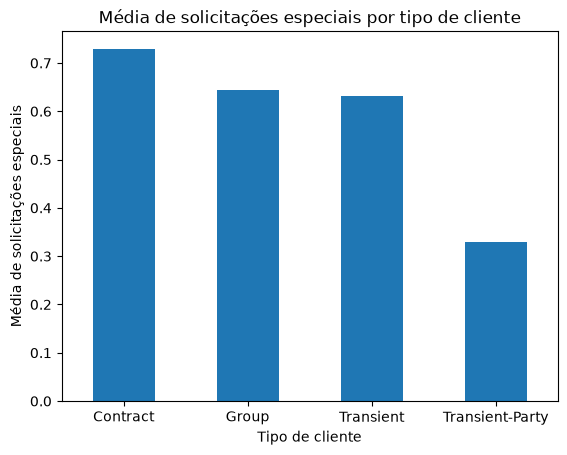

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

special_requests_mean = (
    df.groupby('customer_type')['total_of_special_requests']
      .mean()
)

display(special_requests_mean)

special_requests_mean.plot(
    kind='bar'
)

plt.title('Média de solicitações especiais por tipo de cliente')
plt.xlabel('Tipo de cliente')
plt.ylabel('Média de solicitações especiais')

plt.xticks(rotation=0)

plt.show()

#### 4.40 - Qual tipo de cliente apresenta maior média?

Resposta: Os clientes do tipo `Contract` apresentam a maior média, com aproximadamente 0,729 solicitação especial por reserva.

#### 4.41 - Qual tipo de cliente apresenta menor média?

Resposta: Os clientes do tipo `Transient-Party` apresentam a menor média, com aproximadamente 0,329 solicitação especial por reserva.

#### 4.42 - As diferenças entre os grupos parecem relevantes?

Resposta: A diferença mais evidente ocorre no grupo `Transient-Party`, cuja média é consideravelmente menor que a dos demais. As médias de `Group` e `Transient` são semelhantes, enquanto `Contract` apresenta uma média um pouco maior. Entretanto, apenas o gráfico não permite afirmar se essas diferenças são estatisticamente significativas.

#### 4.43 - Que interpretação de negócio poderia ser levantada a partir desse padrão?

Resposta: Os clientes do tipo `Contract` parecem demandar mais serviços ou adaptações especiais, enquanto os clientes `Transient-Party` fazem menos solicitações. O hotel poderia considerar esses padrões no planejamento do atendimento e na personalização dos serviços para cada perfil de cliente.

## 5. Investigação de outliers

Foram escolhidos `lead_time` e `adr`, pois os histogramas e boxplots anteriores indicaram caudas longas e valores extremos nesses atributos. A regra de 1,5 × IQR considera como possíveis outliers os valores abaixo de $Q1 - 1{,}5 \times IQR$ ou acima de $Q3 + 1{,}5 \times IQR$.

,Q1,Q3,IQR,limite_inferior,limite_superior,possiveis_outliers,percentual
atributo,,,,,,,
lead_time,18.00,160.0,142.00,-195.000,373.000,3005,2.517
adr,69.29,126.0,56.71,-15.775,211.065,3793,3.177


C:\Users\rewel\AppData\Local\Temp\ipykernel_17920\2710071272.py:35: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(df['lead_time'].dropna(), vert=True)
C:\Users\rewel\AppData\Local\Temp\ipykernel_17920\2710071272.py:40: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['adr'].dropna(), vert=True)


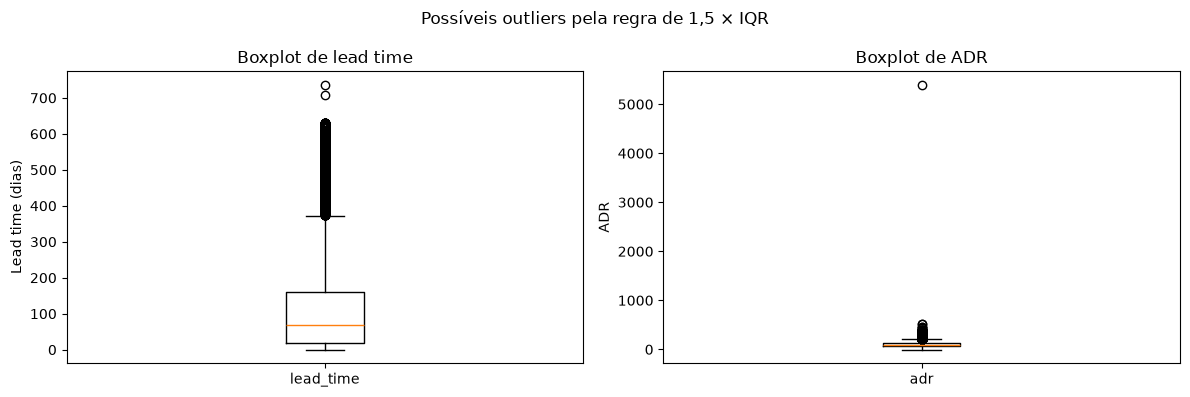

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')

def resumo_outliers_iqr(dataframe, colunas):
    resultados = []

    for coluna in colunas:
        serie = dataframe[coluna].dropna()
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inferior = q1 - 1.5 * iqr
        limite_superior = q3 + 1.5 * iqr
        mascara = (dataframe[coluna] < limite_inferior) | (dataframe[coluna] > limite_superior)

        resultados.append({
            'atributo': coluna,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'limite_inferior': limite_inferior,
            'limite_superior': limite_superior,
            'possiveis_outliers': int(mascara.sum()),
            'percentual': mascara.mean() * 100
        })

    return pd.DataFrame(resultados).set_index('atributo')

resumo_outliers = resumo_outliers_iqr(df, ['lead_time', 'adr'])
display(resumo_outliers.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].boxplot(df['lead_time'].dropna(), vert=True)
axes[0].set_title('Boxplot de lead time')
axes[0].set_ylabel('Lead time (dias)')
axes[0].set_xticks([1], ['lead_time'])

axes[1].boxplot(df['adr'].dropna(), vert=True)
axes[1].set_title('Boxplot de ADR')
axes[1].set_ylabel('ADR')
axes[1].set_xticks([1], ['adr'])

plt.suptitle('Possíveis outliers pela regra de 1,5 × IQR')
plt.tight_layout()
plt.show()

### 5.9 - Quantos registros são classificados como possíveis outliers?

Resposta: Para `lead_time`, $Q1 = 18$, $Q3 = 160$ e $IQR = 142$. Os limites são -195 e 373 dias; assim, 3.005 registros (2,52%) são classificados como possíveis outliers, todos acima do limite superior. Para `adr`, $Q1 = 69{,}29$, $Q3 = 126{,}00$ e $IQR = 56{,}71$. Os limites são -15,775 e 211,065; 3.793 registros (3,18%) ficam fora deles.

### 5.10 - Os valores identificados aparecem também nos boxplots?

Resposta: Sim. Os pontos acima de 373 dias em `lead_time` e acima de 211,065 em `adr` aparecem além dos bigodes. Em `adr`, o valor máximo de 5.400 é especialmente distante; valores negativos, embora existentes no conjunto, não ultrapassam o limite inferior calculado.

### 5.11 - Você removeria esses registros? Justifique.

Resposta: Não removeria todos automaticamente. Reservas feitas com mais de 373 dias de antecedência e diárias acima de 211,065 podem ser raras, mas plausíveis em períodos de alta demanda, categorias especiais ou estadias com outra composição de hóspedes. Antes de decidir, seria necessário validar os registros com regras de negócio. O ADR de 5.400 e valores negativos merecem verificação individual por possível erro, ajuste ou estorno. Para análises sensíveis a extremos, compararia resultados com e sem esses casos ou empregaria medidas robustas, documentando qualquer exclusão.

## 6. Correlação entre atributos numéricos

A correlação de Pearson mede associação linear, não causalidade. A matriz completa é calculada abaixo; a tabela ordena os pares distintos pela correlação em módulo, e o mapa de calor destaca atributos relevantes para a investigação.

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
is_canceled,1.000,0.293,0.017,0.008,-0.006,-0.002,0.025,0.060,0.005,-0.032,-0.085,0.110,-0.057,-0.144,-0.083,-0.021,0.054,0.048,-0.195,-0.235
lead_time,0.293,1.000,0.040,0.127,0.002,0.086,0.166,0.120,-0.038,-0.021,-0.124,0.086,-0.074,0.000,-0.070,0.151,0.170,-0.063,-0.116,-0.096
arrival_date_year,0.017,0.040,1.000,-0.541,-0.000,0.021,0.031,0.030,0.055,-0.013,0.010,-0.120,0.029,0.031,0.063,0.259,-0.056,0.198,-0.014,0.109
arrival_date_week_number,0.008,0.127,-0.541,1.000,0.067,0.018,0.016,0.026,0.006,0.010,-0.030,0.036,-0.021,0.006,-0.031,-0.077,0.023,0.076,0.002,0.026
arrival_date_day_of_month,-0.006,0.002,-0.000,0.067,1.000,-0.016,-0.028,-0.002,0.015,-0.000,-0.006,-0.027,-0.000,0.011,0.001,0.045,0.023,0.030,0.009,0.003
stays_in_weekend_nights,-0.002,0.086,0.021,0.018,-0.016,1.000,0.499,0.092,0.046,0.018,-0.087,-0.013,-0.043,0.063,0.141,0.067,-0.054,0.049,-0.019,0.073
stays_in_week_nights,0.025,0.166,0.031,0.016,-0.028,0.499,1.000,0.093,0.044,0.020,-0.097,-0.014,-0.049,0.096,0.182,0.182,-0.002,0.065,-0.025,0.068
adults,0.060,0.120,0.030,0.026,-0.002,0.092,0.093,1.000,0.030,0.018,-0.146,-0.007,-0.108,-0.052,-0.036,0.208,-0.008,0.231,0.015,0.123
children,0.005,-0.038,0.055,0.006,0.015,0.046,0.044,0.030,1.000,0.024,-0.033,-0.025,-0.021,0.049,0.041,0.031,-0.033,0.325,0.056,0.082
babies,-0.032,-0.021,-0.013,0.010,-0.000,0.018,0.020,0.018,0.024,1.000,-0.009,-0.008,-0.007,0.083,0.036,0.019,-0.011,0.029,0.037,0.098


,,correlacao,correlacao_em_modulo
arrival_date_year,arrival_date_week_number,-0.541,0.541
stays_in_weekend_nights,stays_in_week_nights,0.499,0.499
is_repeated_guest,previous_bookings_not_canceled,0.418,0.418
agent,company,0.351,0.351
children,adr,0.325,0.325
is_canceled,lead_time,0.293,0.293
arrival_date_year,company,0.259,0.259
is_repeated_guest,company,-0.245,0.245
is_canceled,total_of_special_requests,-0.235,0.235
adults,adr,0.231,0.231


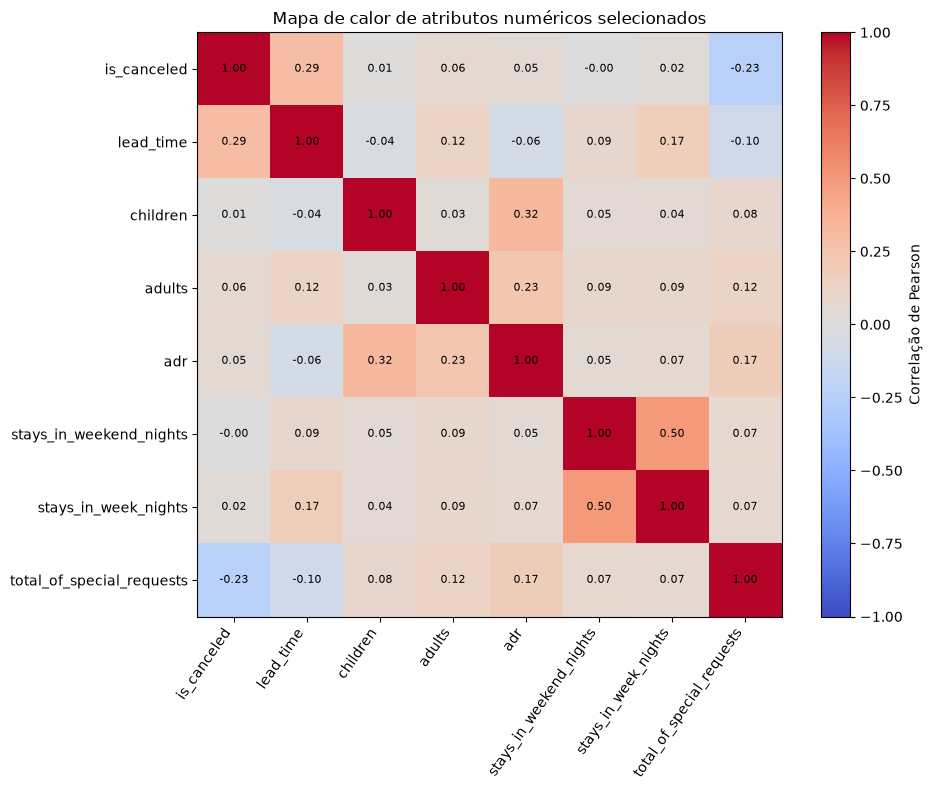

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hotel_bookings.csv')
matriz_correlacao = df.corr(numeric_only=True)
display(matriz_correlacao.round(3))

triangulo_superior = np.triu(np.ones(matriz_correlacao.shape), k=1).astype(bool)
pares_correlacao = (
    matriz_correlacao.where(triangulo_superior)
    .stack()
    .rename('correlacao')
    .to_frame()
)
pares_correlacao['correlacao_em_modulo'] = pares_correlacao['correlacao'].abs()
pares_correlacao = pares_correlacao.sort_values('correlacao_em_modulo', ascending=False)
display(pares_correlacao.head(10).round(3))

atributos_selecionados = [
    'is_canceled', 'lead_time', 'children', 'adults', 'adr',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'total_of_special_requests'
]
corr_selecionada = matriz_correlacao.loc[atributos_selecionados, atributos_selecionados]

fig, ax = plt.subplots(figsize=(10, 8))
imagem = ax.imshow(corr_selecionada, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(atributos_selecionados)), atributos_selecionados, rotation=55, ha='right')
ax.set_yticks(range(len(atributos_selecionados)), atributos_selecionados)

for i in range(len(atributos_selecionados)):
    for j in range(len(atributos_selecionados)):
        ax.text(j, i, f'{corr_selecionada.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)

fig.colorbar(imagem, ax=ax, label='Correlação de Pearson')
ax.set_title('Mapa de calor de atributos numéricos selecionados')
plt.tight_layout()
plt.show()

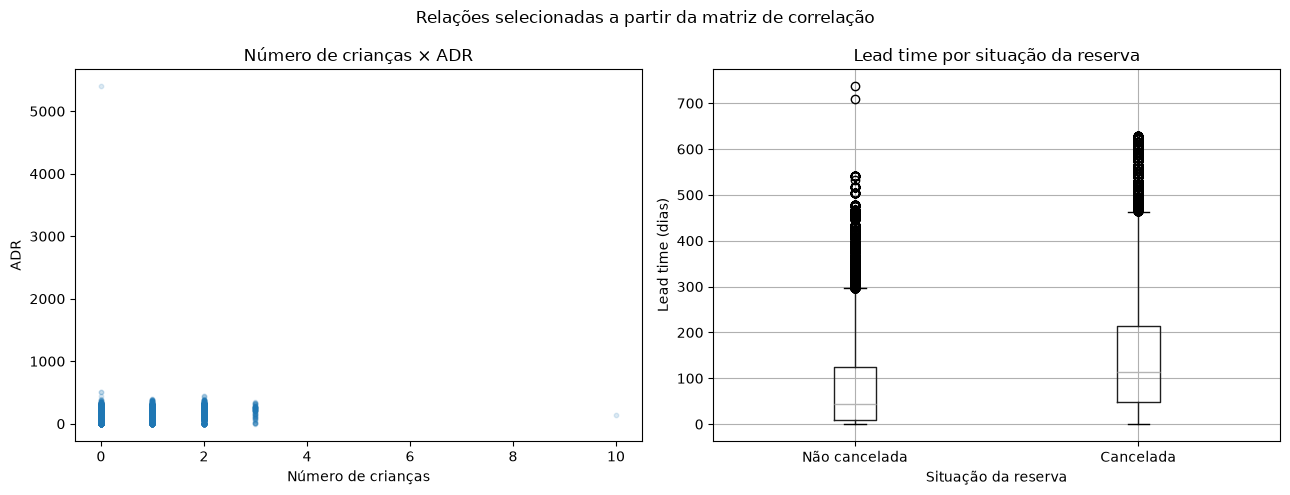

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(df['children'], df['adr'], alpha=0.15, s=10)
axes[0].set_title('Número de crianças × ADR')
axes[0].set_xlabel('Número de crianças')
axes[0].set_ylabel('ADR')

df.boxplot(column='lead_time', by='is_canceled', ax=axes[1])
axes[1].set_title('Lead time por situação da reserva')
axes[1].set_xlabel('Situação da reserva')
axes[1].set_ylabel('Lead time (dias)')
axes[1].set_xticklabels(['Não cancelada', 'Cancelada'])

plt.suptitle('Relações selecionadas a partir da matriz de correlação')
plt.tight_layout()
plt.show()

### 6.12 - Quais pares apresentam as maiores correlações em módulo?

Resposta: Entre atributos originais distintos, os maiores valores são `arrival_date_year` × `arrival_date_week_number` (-0,541), `stays_in_weekend_nights` × `stays_in_week_nights` (0,499), `is_repeated_guest` × `previous_bookings_not_canceled` (0,418), `agent` × `company` (0,351) e `children` × `adr` (0,325). Também se destacam `is_canceled` × `lead_time` (0,293) e `is_canceled` × `total_of_special_requests` (-0,235). Não há correlação linear muito forte entre atributos originais.

### 6.13 - As correlações mais fortes são coerentes com os scatter plots?

Resposta: Sim, com ressalvas. O boxplot confirma que reservas canceladas têm `lead_time` mais alto, coerente com a correlação positiva de 0,293. O gráfico de `children` × `adr` sugere aumento do ADR quando há crianças, mas mostra grupos verticais e grande dispersão, portanto a relação de 0,325 não representa uma linha bem definida. Já `lead_time` × `adr` (-0,063) e duração total × `adr` (0,068, calculada anteriormente) apresentam nuvens muito dispersas, como esperado para correlações próximas de zero.

### 6.14 - Existe alguma correlação que possa ser enganosa?

Resposta: Sim. `arrival_date_year` e `arrival_date_week_number` refletem a janela temporal incompleta do conjunto, não necessariamente um fenômeno de negócio. `agent` e `company` são identificadores codificados numericamente e possuem muitos valores ausentes; calcular Pearson para seus códigos pode produzir uma associação sem significado quantitativo. A relação entre `children` e `adr` também pode sofrer influência do tipo de hotel, do mês, da ocupação e de tarifas familiares. Além disso, correlação com `is_canceled`, embora matematicamente válida como correlação ponto-bisserial, compara uma variável binária a uma numérica e deve ser interpretada como diferença entre grupos.

### 6.15 - Qual relação merece investigação posterior?

Resposta: A relação entre `lead_time` e cancelamento merece prioridade. A correlação é moderada (0,293), mas a mediana de antecedência passa de 45 dias nas reservas não canceladas para 113 dias nas canceladas. Essa diferença tem utilidade operacional e pode ajudar um modelo de risco de cancelamento, desde que seja analisada junto com hotel, canal, segmento, depósito, tarifa e sazonalidade.

## 7. Síntese: o que os dados revelam?

1. **As reservas tendem a ser feitas com antecedência relativamente curta.** Cerca de 60,33% possuem `lead_time` de até 100 dias e a mediana é 69 dias. A distribuição é assimétrica à direita e chega a 737 dias, como mostra o histograma.

2. **O ADR típico está próximo de 95, mas a distribuição possui extremos.** A mediana é 94,575 e a média é 101,831; a diferença e o valor máximo de 5.400 evidenciam assimetria positiva. Pela regra de 1,5 × IQR, 3.793 reservas (3,18%) são possíveis outliers de ADR.

3. **O City Hotel apresenta maior risco observado de cancelamento.** Foram canceladas 41,73% de suas reservas, contra 27,76% no Resort Hotel, diferença visível tanto no gráfico absoluto quanto na comparação proporcional.

4. **Maior antecedência está associada a cancelamento.** A mediana de `lead_time` é 113 dias entre reservas canceladas e 45 dias entre não canceladas; a correlação entre as variáveis é 0,293.

5. **A demanda apresenta sazonalidade.** Agosto lidera com 13.877 reservas, seguido de julho com 12.661, enquanto janeiro tem o menor volume, 5.929. Isso sugere necessidade de ajustar capacidade, equipe e preços ao longo do ano.

6. **Predominam estadias curtas e o ADR quase não varia linearmente com a duração.** Duas e três noites são as durações mais frequentes, com 27.643 e 27.076 reservas. A correlação entre `total_nights` e `adr` é apenas 0,068.

7. **O perfil do cliente está relacionado à demanda por solicitações especiais.** Clientes `Contract` apresentam a maior média (0,729 por reserva), enquanto `Transient-Party` apresenta a menor (0,329), o que pode orientar planejamento e personalização do atendimento.

### Questões para uma próxima etapa de mineração de dados

1. Com que precisão é possível prever o cancelamento usando apenas informações disponíveis no momento da reserva, evitando vazamento de dados?
2. Quais segmentos de clientes podem ser identificados a partir do comportamento de reserva, duração, canal, ADR e solicitações especiais?
3. Como prever a demanda mensal por tipo de hotel e estimar o efeito conjunto de sazonalidade, antecedência e preço?